In [2]:
import sys

assert sys.version_info >= (3, 7)

from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [3]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

#  data는 입력 데이터로 매트릭스 넘파이 배열이고 target은 레이블로 벡터 넘파이 배열이다.
X, y = mnist.data, mnist.target

# 총 70000개의 28 x 28 픽셀 정보가 담겨 있다.
print(X.shape) # (70000, 784)

(70000, 784)


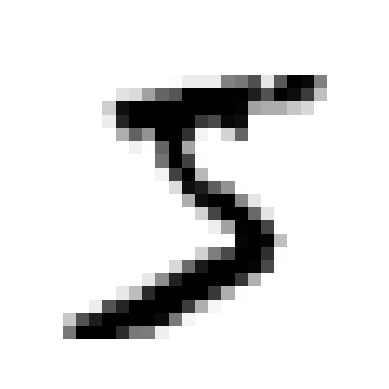

5


In [4]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

# 첫번째 샘플
some_digit = X[0]
plot_digit(some_digit)
plt.show()

# 첫번째 레이블
print(y[0])

# 70000개의 데이터 중 6만개를 훈련 세트, 1만개를 테스트 세트로 분류
# MNIST 데이터 셋은 사전에 잘 섞여 있기 때문에 슬라이싱으로 단순 분류
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [5]:
# 문제를 단순화하여 5이거나, 5가 아니거나를 구분하는 이진 분류기

# 5일 때 True, 나머지는 False
y_train_5 = (y_train == '5')
y_test_5 = (y_test == 5)

from sklearn.linear_model import SGDClassifier

# SGD 분류기를 모델로 사용
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

sgd_clf.predict([some_digit]) # True

array([ True])

In [6]:
# 선택한 모델의 성능 측정
# k = 3인 k-폴드 교차 검증으로 SGDClassifier 모델 평가
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy") # array([0.95035, 0.96035, 0.9604 ])

array([0.95035, 0.96035, 0.9604 ])

In [7]:
# 더미 분류기로 정확도 측정
# 더미 분류기의 기본 설정은 단순히 가장 비율이 높은 클래스를 선택하여 모든 예측에 대해 해당 클래스를 예측값으로 가진다.
# 숫자 5는 전체 데이터에서 약 10%, 즉 5가 아닌 숫자는 90%이므로 더미 분류기는 이진 분류 중 비율이 높은 '5가 아님' 만을 예측한다.
# 따라서, 그저 정답 비율이 높은 것으로 찍기 그 이상 그 이하도 아니지만, 실제로 정확도가 90%이므로
# 이 예제는 정확도를 분류기의 성능 측정 지표로 선호하지 않음을 알려준다.
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy") # array([0.90965, 0.90965, 0.90965])

array([0.90965, 0.90965, 0.90965])

In [8]:
from sklearn.model_selection import cross_val_predict

# k-폴드 교차 검증을 통해 훈련 세트를 3분할 하여 1, 2 데이터 학습 -> 3 데이터 예측 -> 학습 초기화 -> 반복... 하여 전체 세트에 대한 예측값을 반환한다.
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)

print(cm)

# TN FP
# FN TP

# 정밀도는 5라고 예측한 것 중에 실제 정답이 5인 비율, 즉 TP / TP + FP 이다.
# 재현율은 실제 정답이 5인 숫자 중에 모델이 5라고 예측한 비율, 즉 TP / TP + FN 이다.

from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)  # == 3530 / (687 + 3530)
recall_score(y_train_5, y_train_pred)  # == 3530 / (1891 + 3530)



[[53892   687]
 [ 1891  3530]]


0.6511713705958311

In [10]:
from sklearn.metrics import f1_score

# 정밀도와 재현율의 조화 평균을 구하여 F1 점수를 얻을 수 있다.
# 조화 평균은 낮은 값에 높은 비중을 두기 때문에 산술 평균과 같이 어느 한쪽만 높기 보다 양쪽이 높아야 높은 F1 점수를 얻을 수 있다.
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [11]:
# SGDClassifier 분류기는 결정 함수를 통해 각 샘플의 점수를 매긴 뒤, 기준점을 통해
# 기준점보다 값이 크면 양성, 기준점보다 값이 작으면 음성으로 판단하는 메커니즘이다.
# 이 때 기준점을 결정 임곗값이라고 하며, 예를 들어 이 값이 0일 때,
# 어느 샘플의 결정 함수 결과값이 -40이면 음성 클래스, 30이면 양성 클래스로 구분한다.

# 일반적으로, 정밀도와 재현율은 반비례의 관계이기 때문에 트레이드오프가 필요하다.
# 따라서 정밀도를 중요시하고자 한다면 임곗값을 높이고, 재현율을 중요시한다면 임곗값을 내릴 수 있다.

# 예를 들어 임곗값을 20으로 높인다면 7, 15와 같은 샘플은 포함하지 않아 예측의 정밀도를 높일 수 있고
# 임곗값을 -20으로 낮춘다면 -3, -17와 같은 샘플까지 포함하여 재현율을 높일 수 있다.

# 임곗값을 직접 지정할 수는 없지만, decision_function()을 통해 예측한 점수를 얻을 수 있다.
y_scores = sgd_clf.decision_function([some_digit])
print(y_scores) # array([2164.22030239])

# 간접적으로 임곗값을 0으로 설정
threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred) # array([ True])

# 간접적으로 임곗값을 3000으로 설정 (높은 정밀도의 예시)
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred) # array([ False])


[2164.22030239]
[ True]
[False]


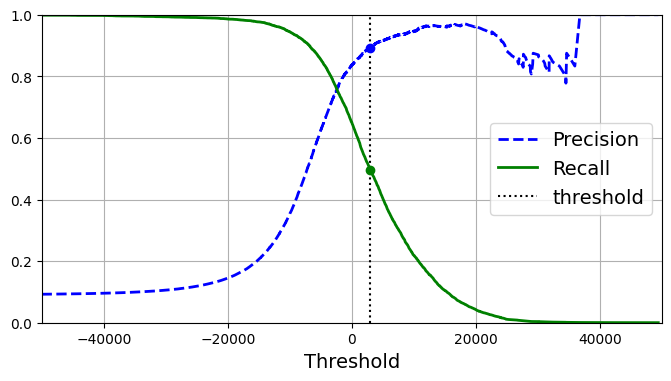

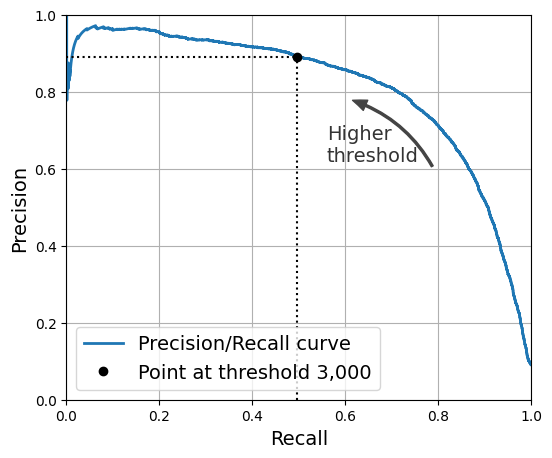

In [12]:
# 그렇다면, 적절한 임곗값을 어떻게 판단할까?
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# 임곗값 배열 : 모든 샘플들의 점수를 중복 없이 오름 차순으로 정렬하고 맨 마지막의 최댓값 하나는 제거한 배열
thresholds
# 정밀도 배열 : 구한 샘플의 점수를 임곗값으로 했을 때, 전체 샘플에 대한 정밀도를 담은 배열
precisions

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")


idx = (thresholds >= threshold).argmax()  # 첫 번째 index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

import matplotlib.patches as patches  # 추가 코드 – 구부러진 화살표를 그리기 위해서

plt.figure(figsize=(6, 5))  # 추가 코드

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

In [13]:
# 만약 정밀도를 최소 90% 달성하는 것이 목표라면, 재현율을 최소한으로 손해보는 임곗값을 찾아야 한다.
# 임곗값은 오름차순으로 정렬되어 있으므로, 그에 따른 정밀도 배열 또한 일반적으로 오름차순의 형태를 보인다.
# 따라서 정밀도가 0.9가 되는 최초의 지점을 찾는다면 그것이 90%의 정밀도를 만족하면서 최대의 재현율을 얻을 수 있는 임곗값이 된다.
# 하지만, 정밀도는 진동할 수 있으므로 0.9 다음에 0.88과 같이 소폭 하락할 수 있다는 점 또한 존재한다.

idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision # np.float64(3370.0194991439557)

y_train_pred_90 = (y_scores >= threshold_for_90_precision)
precision_score(y_train_5, y_train_pred_90)

recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision



0.4799852425751706

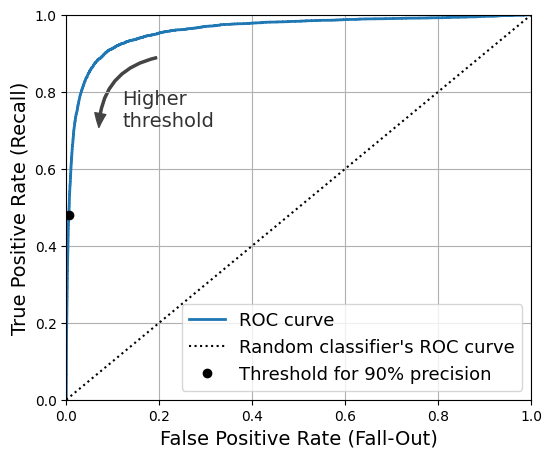

np.float64(0.9604938554008616)

In [17]:
from sklearn.metrics import roc_curve

# ROC 곡선은 진짜 양성 비율 / 거짓 양성 비율, 즉 재현율 / 음성인데 양성으로 분류된 음성 샘플의 비율이다.
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

# 90% 정밀도 기준 TPR, FPR 값
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # 추가 코드
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# 추가 코드 – 그림 3–7을 그리고 저장합니다
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

# 그림에서, 가장 이상적인 결과는 TPR = 1.0, FPR = 0.0, 즉 양성 클래스를 전부 양성이라고 판단하며 음성 클래스에 대해서는 하나도 양성이라고 판단하지 않는 것이다.
# 점선 y=x 에 가까울수록 TPR와 FRP이 같아 옳은 결과를 내는 정도에 대해 틀린 결과를 내는 정도도 같은 매우 낮은 성능의 모델임을 의미한다.
# 랜덤 분류기는 ROC 곡선이 이 점선을 따르므로 형편없는 분류기임을 알 수 있다.

# 따라서 곡선 아래의 면적, AUC를 측정해 1에 가까울수록 일반적으로 성능이 좋으며(99% vs 1%와 같은 데이터 불균형의 착시 또는 과대적합 제외), 0.5에 가까울수록 성능이 나쁘다라고 판단할 수 있다.

from sklearn.metrics import roc_auc_score

# ROC 곡선의 아래 면적 AUC
roc_auc_score(y_train_5, y_scores) # np.float64(0.9604938554008616)

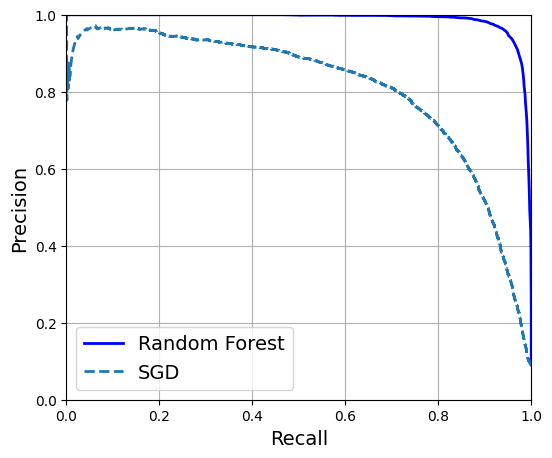

In [20]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")
y_probas_forest[:2]

y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)

plt.figure(figsize=(6, 5))  # 추가 코드

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# 추가 코드 – 그림 3–8을 그리고 저장합니다
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

In [21]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5  # 양성 확률 ≥ 50%
f1_score(y_train_5, y_train_pred_forest)

roc_auc_score(y_train_5, y_scores_forest)

precision_score(y_train_5, y_train_pred_forest)

recall_score(y_train_5, y_train_pred_forest)

0.8725327430363402